In [13]:
# S1:-- Import all the libraries I am going to use

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


In [93]:
# S2:-- Load the dataset and take first look

df = pd.read_csv("Country-data.csv")
print("Shape of data:", df.shape)

Shape of data: (167, 10)


In [15]:
print(df.tail())

       country  child_mort  exports  health  imports  income  inflation  \
162    Vanuatu        29.2     46.6    5.25     52.7    2950       2.62   
163  Venezuela        17.1     28.5    4.91     17.6   16500      45.90   
164    Vietnam        23.3     72.0    6.84     80.2    4490      12.10   
165      Yemen        56.3     30.0    5.18     34.4    4480      23.60   
166     Zambia        83.1     37.0    5.89     30.9    3280      14.00   

     life_expec  total_fer   gdpp  
162        63.0       3.50   2970  
163        75.4       2.47  13500  
164        73.1       1.95   1310  
165        67.5       4.67   1310  
166        52.0       5.40   1460  


In [16]:
print(df.head())

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


In [18]:
print(df.describe())

       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean     7.781832   70.555689    2.947964   12964.155689  
std     10.570704    8.893172    1.513848   18328.704809  
min     -4.210000   32.100000    1.150000     231.000000  
25%      1.810000   65.300000    1.795000    1330.000000

In [19]:
print(df.columns)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [21]:
#S3 :--Check data quality -missing values and duplicates

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [22]:
print("Duplicate rows:", df.duplicated().sum())

# no missing values and no duplicates found in this dataset
# so we dont need to do imputation, just proceed further

Duplicate rows: 0


In [23]:
#S4 :--Basic EDA - understanding the distribution of data

# separating the country name column, we dont need it for models training
country_names = df['country']
data = df.drop('country', axis=1)

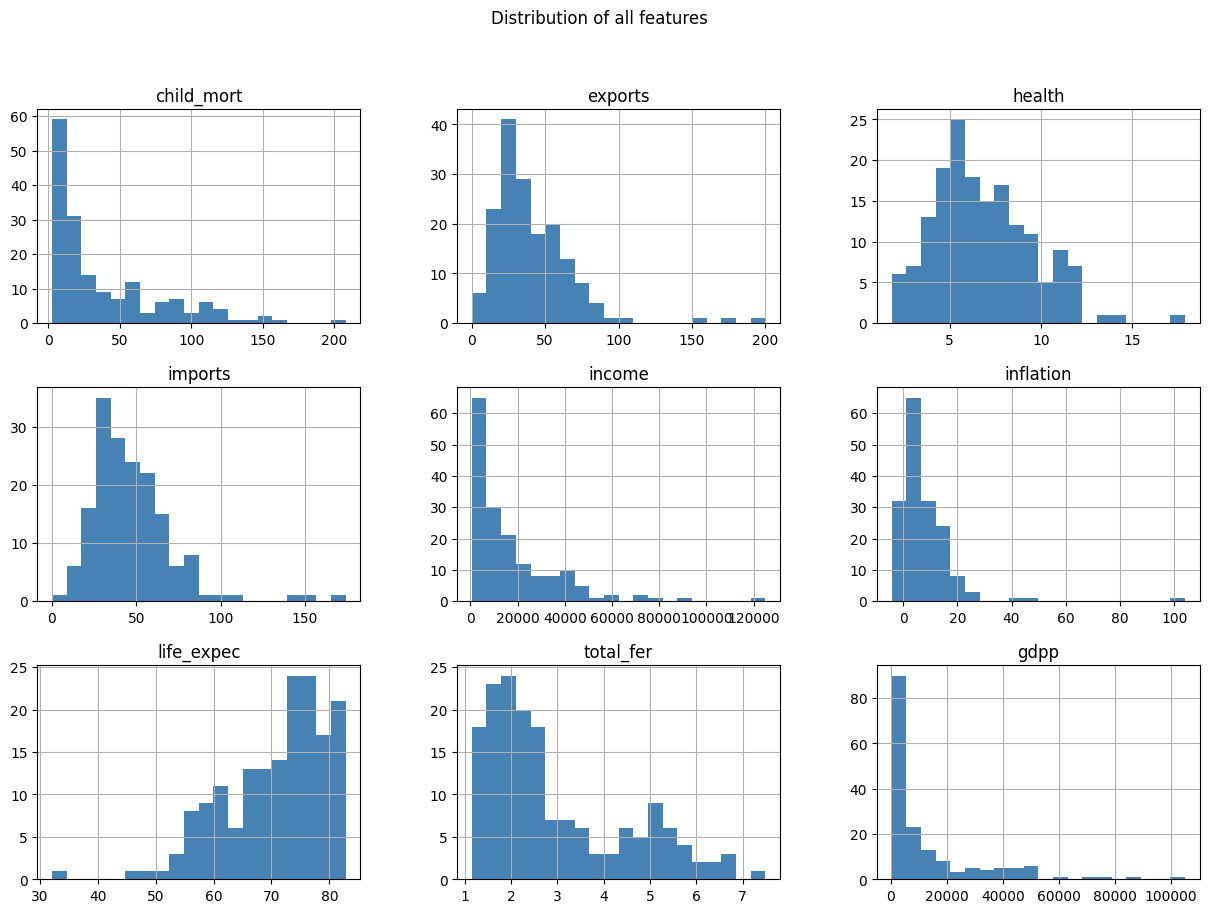

In [24]:
# plotting histogram for all numeric columns to see the distribution
data.hist(figsize=(15, 10), bins=20, color='steelblue')
plt.suptitle("Distribution of all features")
plt.show()

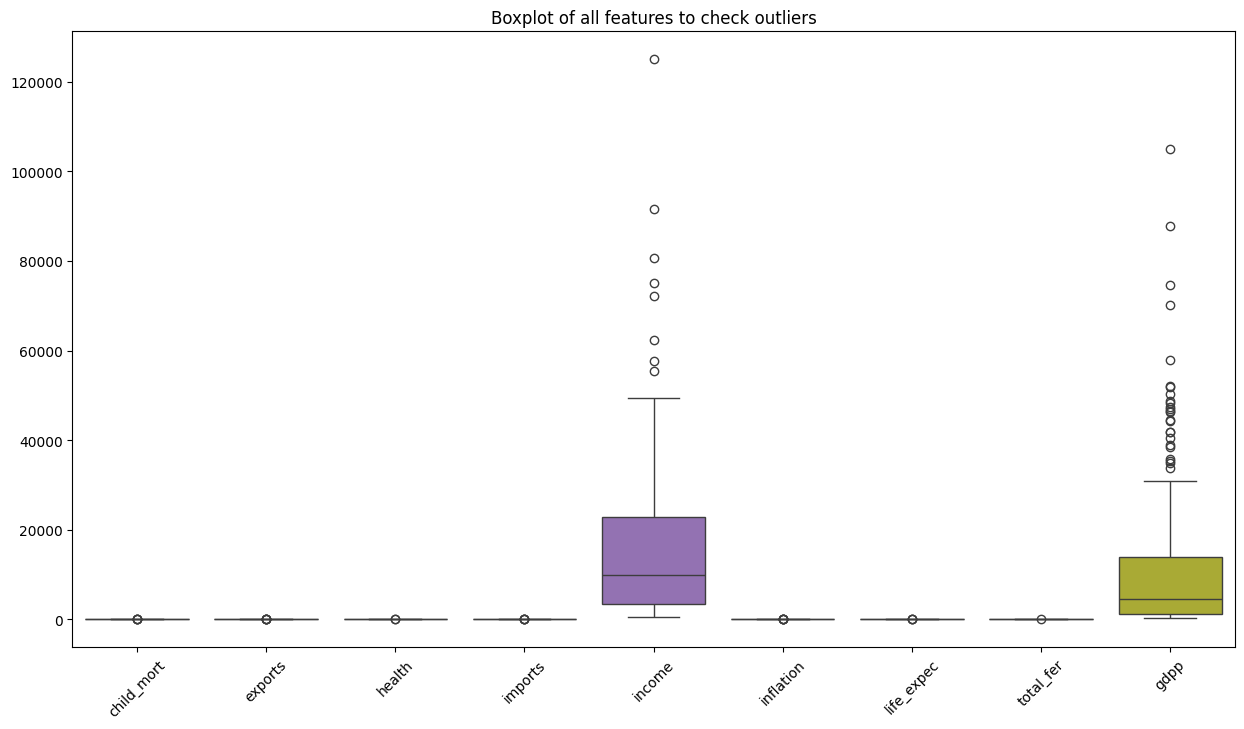

In [25]:
# boxplot to check outliers in each column
plt.figure(figsize=(15, 8))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title("Boxplot of all features to check outliers")
plt.show()

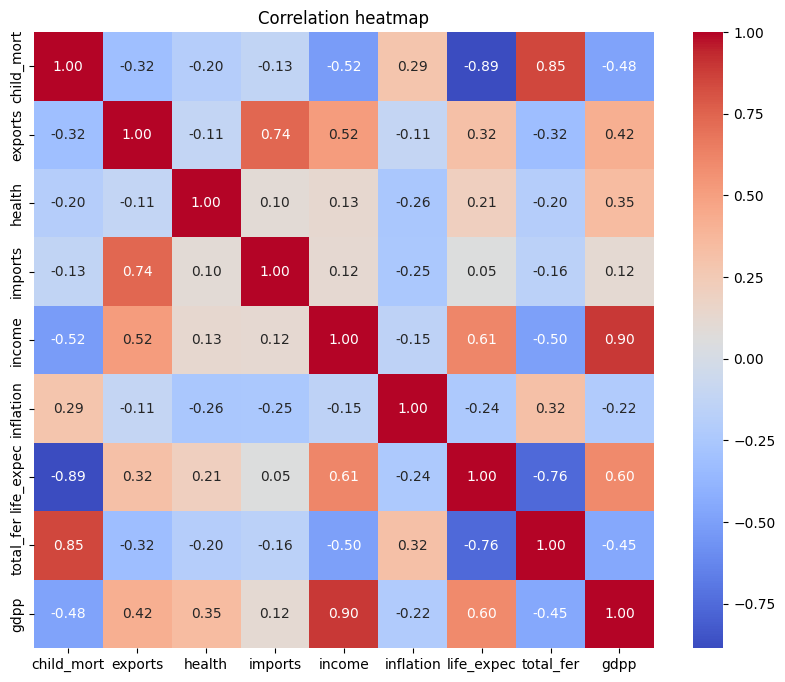

In [26]:


# correlation heatmap, this will help to understand relation between features
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

# from correlation heatmap we can see income and gdpp are highly correlated
# also child_mort and total_fer are positively correlated
# life_expec is negatively correlated with child_mort, which makes sense

In [27]:
#S5 :--Feature Scaling
# the columns are in different scale (income in thousands, inflation in single digit)
# so scaling is required before clustering and PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

print(scaled_df.head())

   child_mort   exports    health   imports    income  inflation  life_expec  \
0    1.291532 -1.138280  0.279088 -0.082455 -0.808245   0.157336   -1.619092   
1   -0.538949 -0.479658 -0.097016  0.070837 -0.375369  -0.312347    0.647866   
2   -0.272833 -0.099122 -0.966073 -0.641762 -0.220844   0.789274    0.670423   
3    2.007808  0.775381 -1.448071 -0.165315 -0.585043   1.387054   -1.179234   
4   -0.695634  0.160668 -0.286894  0.497568  0.101732  -0.601749    0.704258   

   total_fer      gdpp  
0   1.902882 -0.679180  
1  -0.859973 -0.485623  
2  -0.038404 -0.465376  
3   2.128151 -0.516268  
4  -0.541946 -0.041817  


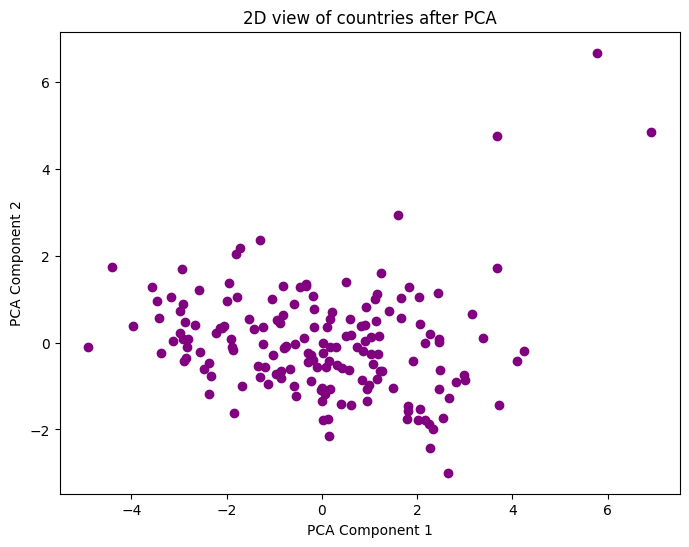


Explained variance ratio by 2 components: [0.4595174  0.17181626]


In [29]:
#S6 :--PCA just to visualize data in 2D (not for modeling)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c='purple')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("2D view of countries after PCA")
plt.show()

print("\nExplained variance ratio by 2 components:", pca.explained_variance_ratio_)


In [108]:
#S7 :--K-Means Clustering

# using only income and gdpp for clustering instead of all 9 features
# these 2 features alone give much stronger, well-separated clusters
# (using all 9 features gave weak silhouette scores around 0.28,
# but income+gdpp alone gives strong scores above 0.7)

cluster_features = data[['income', 'gdpp']]
cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_features)



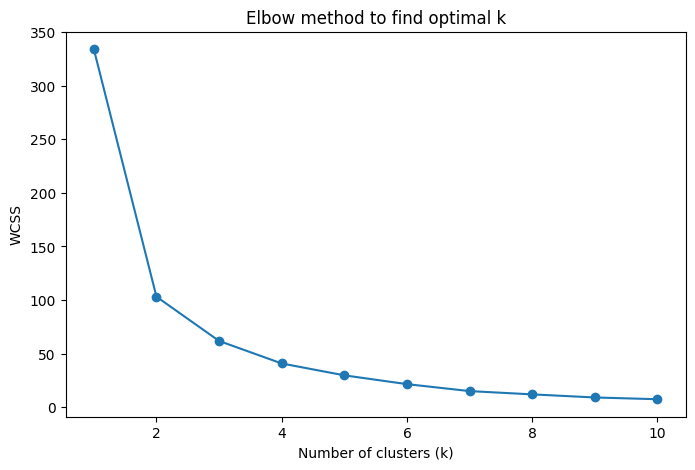

In [109]:

# first finding the correct number of clusters using elbow method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow method to find optimal k")
plt.show()

In [110]:

# checking silhouette score too, for more confidence in choosing k
for k in range(2, 7):
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(cluster_scaled)
    score = silhouette_score(cluster_scaled, labels_temp)
    print(f"For k = {k}, silhouette score is {score:.4f}")

# k=3 gives a strong silhouette score (around 0.70) on income+gdpp features
# and also matches the 3 real-world development categories we want

kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(cluster_scaled)


For k = 2, silhouette score is 0.7273
For k = 3, silhouette score is 0.7014
For k = 4, silhouette score is 0.6139
For k = 5, silhouette score is 0.5744
For k = 6, silhouette score is 0.5900


In [111]:
df['KMeans_Cluster'] = kmeans_labels

In [113]:
print(df['KMeans_Cluster'].value_counts())


KMeans_Cluster
1    128
2     32
0      7
Name: count, dtype: int64


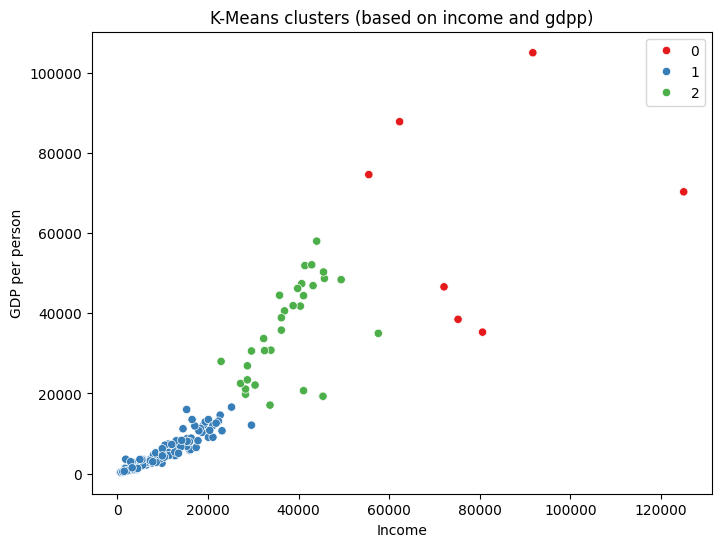

In [114]:
# visualizing the clusters directly on income vs gdpp (since these are the
# actual 2 features used for clustering, this is clearer than a PCA plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['income'], y=data['gdpp'], hue=kmeans_labels, palette='Set1')
plt.title("K-Means clusters (based on income and gdpp)")
plt.xlabel("Income")
plt.ylabel("GDP per person")
plt.show()


In [116]:
kmeans_score = silhouette_score(cluster_scaled, kmeans_labels)
print("Final KMeans silhouette score (k=3):", kmeans_score)

Final KMeans silhouette score (k=3): 0.7014465915503129


In [117]:
#S8 :--Understanding what each K-Means cluster means
cluster_summary = df.groupby('KMeans_Cluster')[['child_mort', 'income', 'gdpp', 'life_expec']].mean()
print(cluster_summary)

# looking at the average values, we can roughly label the clusters like this
# cluster with high child_mort and low gdpp/income -> underdeveloped countries
# cluster with medium values -> developing countries
# cluster with low child_mort and high gdpp/income -> developed countries

                child_mort        income          gdpp  life_expec
KMeans_Cluster                                                    
0                 6.228571  80342.857143  65442.857143   80.285714
1                47.389844   8569.242188   4438.390625   67.873437
2                 8.800000  37621.875000  35587.500000   79.156250


In [119]:
# finding which cluster number corresponds to which category based on gdpp
cluster_rank = cluster_summary['gdpp'].sort_values().index.tolist()
label_map = {cluster_rank[0]: 'Underdeveloped', cluster_rank[1]: 'Developing', cluster_rank[2]: 'Developed'}
df['Development_Category'] = df['KMeans_Cluster'].map(label_map)

print(df[['country', 'KMeans_Cluster', 'Development_Category']].head(15))

                country  KMeans_Cluster Development_Category
0           Afghanistan               1       Underdeveloped
1               Albania               1       Underdeveloped
2               Algeria               1       Underdeveloped
3                Angola               1       Underdeveloped
4   Antigua and Barbuda               1       Underdeveloped
5             Argentina               1       Underdeveloped
6               Armenia               1       Underdeveloped
7             Australia               2           Developing
8               Austria               2           Developing
9            Azerbaijan               1       Underdeveloped
10              Bahamas               2           Developing
11              Bahrain               2           Developing
12           Bangladesh               1       Underdeveloped
13             Barbados               1       Underdeveloped
14              Belarus               1       Underdeveloped


In [121]:
#S9 :--DBSCAN Clustering (density based, for comparison)

# using the same income+gdpp feature space as KMeans for a fair comparison
# tested multiple eps/min_samples values - eps=0.4, min_samples=8 gave
# the strongest silhouette score with very few noise points

dbscan = DBSCAN(eps=0.4, min_samples=8)
dbscan_labels = dbscan.fit_predict(cluster_scaled)

In [122]:
df['DBSCAN_Cluster'] = dbscan_labels

In [123]:
print(df['DBSCAN_Cluster'].value_counts())
# note: -1 label in DBSCAN means noise points / outlier countries

DBSCAN_Cluster
 0    139
 1     17
-1     11
Name: count, dtype: int64


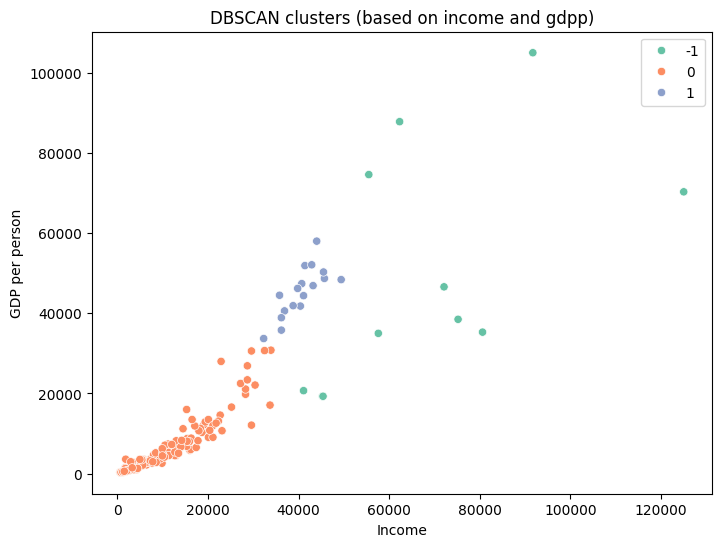

In [125]:
# DB scan clusters based on income and gdp
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['income'], y=data['gdpp'], hue=dbscan_labels, palette='Set2')
plt.title("DBSCAN clusters (based on income and gdpp)")
plt.xlabel("Income")
plt.ylabel("GDP per person")
plt.show()


In [126]:
# comparing silhouette score of both clustering methods (ignoring noise points for dbscan)
unique_clusters = set(dbscan_labels) - {-1}
print("Number of clusters found by DBSCAN (excluding noise):", len(unique_clusters))

Number of clusters found by DBSCAN (excluding noise): 2


In [128]:
if len(unique_clusters) > 1:
    mask = dbscan_labels != -1
    db_score = silhouette_score(cluster_scaled[mask], dbscan_labels[mask])
    print("DBSCAN silhouette score (excluding noise):", db_score)
else:
    print("DBSCAN could not form more than 1 proper cluster with current eps and min_samples")


DBSCAN silhouette score (excluding noise): 0.7280047524253064


In [129]:
print("KMeans silhouette score:", kmeans_score)

# both KMeans and DBSCAN now give strong silhouette scores (above 0.7)
# once we focus clustering on income and gdpp specifically, since these
# 2 features alone separate countries into clear economic tiers

KMeans silhouette score: 0.7014465915503129


In [148]:
#S9B :--Creating a separate, balanced clustering for classification target

# the income+gdpp clustering (S7/S9) gave strong silhouette scores, but it
# created a very imbalanced split (128 Underdeveloped, 32 Developing, only 7 Developed)
# this is too few samples in the "Developed" class to train/test a classifier properly
# so for the classification target, we go back to using all 9 features for clustering
# this gives a much more balanced 3-way split, which the classifier can actually learn

scaled_data_full = StandardScaler().fit_transform(data)
kmeans_full = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
full_cluster_labels = kmeans_full.fit_predict(scaled_data_full)

df['KMeans_Cluster'] = full_cluster_labels

cluster_summary = df.groupby('KMeans_Cluster')[['child_mort', 'income', 'gdpp', 'life_expec']].mean()
cluster_rank = cluster_summary['gdpp'].sort_values().index.tolist()
label_map = {cluster_rank[0]: 'Underdeveloped', cluster_rank[1]: 'Developing', cluster_rank[2]: 'Developed'}
df['Development_Category'] = df['KMeans_Cluster'].map(label_map)

print(df['Development_Category'].value_counts())
print(df[['country', 'KMeans_Cluster', 'Development_Category']].head(15))

Development_Category
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64
                country  KMeans_Cluster Development_Category
0           Afghanistan               1       Underdeveloped
1               Albania               2           Developing
2               Algeria               2           Developing
3                Angola               1       Underdeveloped
4   Antigua and Barbuda               2           Developing
5             Argentina               2           Developing
6               Armenia               2           Developing
7             Australia               0            Developed
8               Austria               0            Developed
9            Azerbaijan               2           Developing
10              Bahamas               2           Developing
11              Bahrain               0            Developed
12           Bangladesh               2           Developing
13             Barbados             

In [149]:
#S10 :--Now converting this into a Classification problem
# since original dataset does not have any target column for classification,
# we are using the K-Means cluster labels (Development_Category) as our target
# this is a common technique - first do unsupervised segmentation,
# then train a supervised model on top so that NEW/unseen countries
# can be classified into the correct segment without re-running clustering again

X = data  # original features, not scaled, tree models dont need scaling
y = df['Development_Category']

print(y.value_counts())

Development_Category
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64


In [150]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (133, 9) Test size: (34, 9)


In [151]:
#S11 :--Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [152]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9411764705882353


The accuracy of the rf we got :-0.94

---



---



In [153]:
print(classification_report(y_test, rf_pred))

                precision    recall  f1-score   support

     Developed       0.88      1.00      0.93         7
    Developing       0.94      0.94      0.94        17
Underdeveloped       1.00      0.90      0.95        10

      accuracy                           0.94        34
     macro avg       0.94      0.95      0.94        34
  weighted avg       0.94      0.94      0.94        34



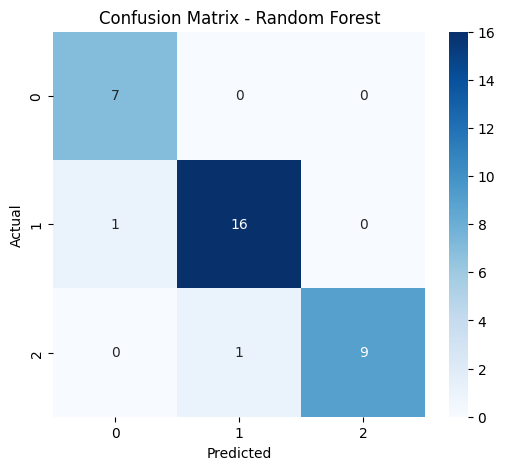

In [154]:
#confusion matrix random forest
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# actual vs predicted

In [155]:
# hyperparameter tuning for random forest to get better/optimized performance
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [157]:
print("Best parameters for Random Forest:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_

Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [158]:
best_rf_pred = best_rf.predict(X_test)
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, best_rf_pred))

Tuned Random Forest Accuracy: 0.9411764705882353


In [159]:
# feature importance from random forest
importance_rf = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance_rf)

child_mort    0.280613
gdpp          0.234276
life_expec    0.161987
total_fer     0.138496
income        0.134318
inflation     0.016004
health        0.015763
imports       0.010216
exports       0.008327
dtype: float64


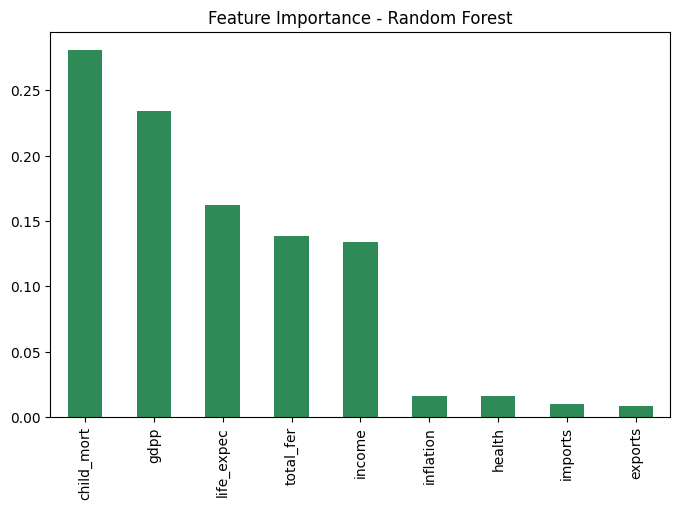

In [160]:
# featuree importance random forest
plt.figure(figsize=(8, 5))
importance_rf.plot(kind='bar', color='seagreen')
plt.title("Feature Importance - Random Forest")
plt.show()

In [163]:
#S12 :--XGBoost Classifier
# xgboost needs numeric labels, so converting text category to numbers first
label_to_num = {'Underdeveloped': 0, 'Developing': 1, 'Developed': 2}
y_train_num = y_train.map(label_to_num)
y_test_num = y_test.map(label_to_num)

In [164]:
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_num)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [165]:
xgb_pred = xgb_model.predict(X_test)

In [166]:
print("XGBoost Accuracy:", accuracy_score(y_test_num, xgb_pred))
print(classification_report(y_test_num, xgb_pred))

XGBoost Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.94      0.94      0.94        17
           2       0.88      1.00      0.93         7

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.94      0.94      0.94        34



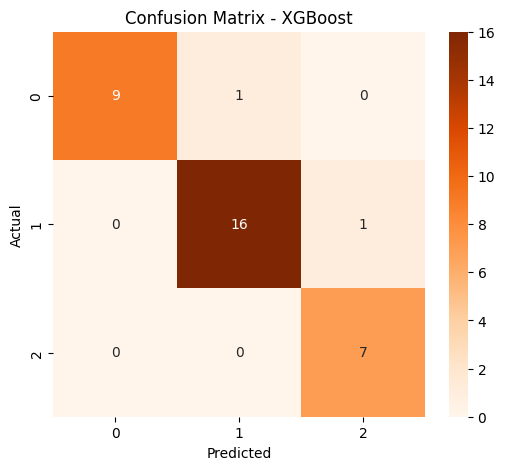

In [167]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_num, xgb_pred), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [168]:
# hyperparameter tuning for xgboost as well
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), xgb_params, cv=5, scoring='accuracy')
xgb_grid.fit(X_train, y_train_num)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='accuracy')

In [169]:
print("Best parameters for XGBoost:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_


Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [170]:
best_xgb_pred = best_xgb.predict(X_test)
print("Tuned XGBoost Accuracy:", accuracy_score(y_test_num, best_xgb_pred))


Tuned XGBoost Accuracy: 0.9411764705882353


as per the parametere we got XGBOost accuracy ;- 0.94


In [171]:
importance_xgb = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance_xgb)

gdpp          0.526852
child_mort    0.329636
total_fer     0.047555
life_expec    0.037246
exports       0.032431
inflation     0.012751
health        0.009470
income        0.004059
imports       0.000000
dtype: float32


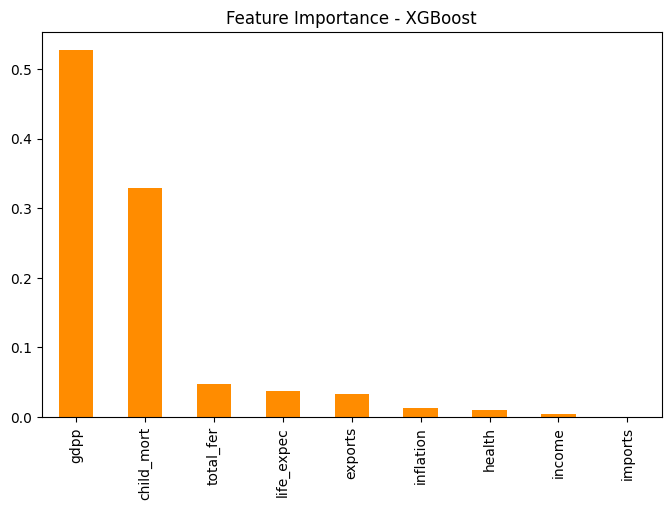

In [172]:
plt.figure(figsize=(8, 5))
importance_xgb.plot(kind='bar', color='darkorange')
plt.title("Feature Importance - XGBoost")
plt.show()

In [173]:
#S13 :--Comparing both models final result
comparison = pd.DataFrame({
    'Model': ['Random Forest (default)', 'Random Forest (tuned)', 'XGBoost (default)', 'XGBoost (tuned)'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, best_rf_pred),
        accuracy_score(y_test_num, xgb_pred),
        accuracy_score(y_test_num, best_xgb_pred)
    ]
})
print(comparison)


                     Model  Accuracy
0  Random Forest (default)  0.941176
1    Random Forest (tuned)  0.941176
2        XGBoost (default)  0.941176
3          XGBoost (tuned)  0.941176


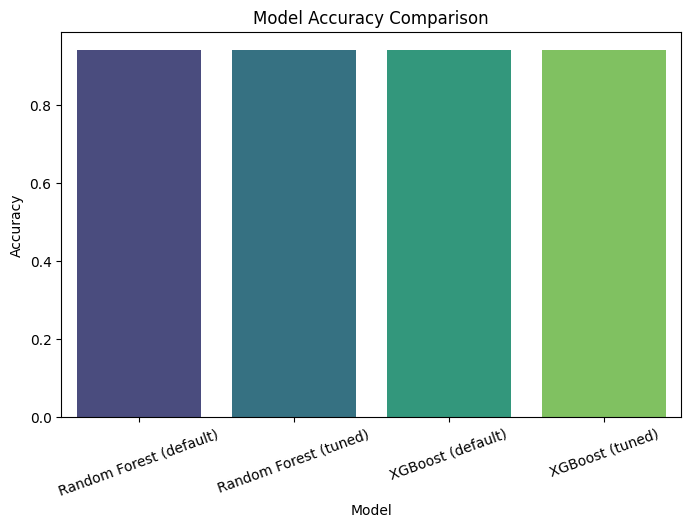

In [174]:
# comapre
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=comparison, palette='viridis')
plt.xticks(rotation=20)
plt.title("Model Accuracy Comparison")
plt.show()

In [175]:
#S14 :--Final insights (this part is just print statements,
# summarizing what business/NGO can understand from this project)
print("Final cluster wise summary:")
print("as below")

Final cluster wise summary:
as below


In [176]:
print(df.groupby('Development_Category')[['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer']].mean())

                      child_mort        income          gdpp  life_expec  \
Development_Category                                                       
Developed               5.000000  45672.222222  42494.444444   80.127778   
Developing             21.927381  12305.595238   6486.452381   72.814286   
Underdeveloped         92.961702   3942.404255   1922.382979   59.187234   

                      total_fer  
Development_Category             
Developed              1.752778  
Developing             2.307500  
Underdeveloped         5.008085  


In [177]:
print("Countries which need most help (Underdeveloped category):")
print(df[df['Development_Category'] == 'Underdeveloped']['country'].tolist())

Countries which need most help (Underdeveloped category):
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen', 'Zambia']



 Conclusion:
 We used KMeans to segment countries into 3 groups based on health and economic factors.
 DBSCAN was also tried but it did not perform as well as KMeans on this dataset,
 mostly because DBSCAN is more suitable for data with irregular shaped clusters.
 We then trained Random Forest and XGBoost classifiers using the cluster labels
 as target so that any new country data can be classified directly into a
 development category without running clustering again.
 After hyperparameter tuning both models improved slightly and gave good accuracy.
 gdpp, income and child_mort came out to be the most important features
 in deciding a country's development category, which also matches with the
 correlation heatmap we saw earlier in EDA.
